In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("seattle-weather.csv")
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
modalities = df.columns
modalities = modalities.drop(["date", "weather"])
modalities = modalities.tolist()
modalities

['precipitation', 'temp_max', 'temp_min', 'wind']

In [5]:
rng = np.random.default_rng(42)
num_clients = 10

time_alpha = 1.0
mode_alpha = 10.0

partitions = {}
missing_modalities = set(modalities)

for client in range(num_clients):
    partitions[client] = pd.DataFrame(df.date)
    for m in modalities:
        partitions[client][m] = pd.Series()

client_alpha = rng.dirichlet([100000.0] * num_clients)
print(f"{client_alpha=}")
for i, row in enumerate(df.itertuples()):
    for m in modalities:
        client_dir = rng.dirichlet(client_alpha)
        client_idx = client_dir.argmax()
        # client_idx[0] *= client_mask[0]  # either 1 or 0, where 0 means this client cannot have this modality
        partitions[client_idx].loc[i, m] = getattr(row, m)

print("Done partitioning!")

client_alpha=array([0.10003685, 0.10017788, 0.09932518, 0.09998093, 0.09993521,
       0.1002187 , 0.09996139, 0.10008834, 0.10005711, 0.1002184 ])
Done partitioning!


/var/folders/kn/2_n0f_tn41j9_rj_8lcvx4g00000gn/T/ipykernel_15423/4115451455.py:13: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  partitions[client][m] = pd.Series()
/var/folders/kn/2_n0f_tn41j9_rj_8lcvx4g00000gn/T/ipykernel_15423/4115451455.py:13: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  partitions[client][m] = pd.Series()
/var/folders/kn/2_n0f_tn41j9_rj_8lcvx4g00000gn/T/ipykernel_15423/4115451455.py:13: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  partitions[client][m] = pd.Series()
/var/folders/kn/2_n0f_tn41j9_rj_8lcvx4g00000gn/T/ipykernel_15423/4115451455.py:13: FutureWarning: The default dtype for empty Series will be 'object' inst

In [6]:
partitions[1]

,date,precipitation,temp_max,temp_min,wind
0,2012-01-01,0.0,NaN,NaN,4.7
1,2012-01-02,NaN,NaN,2.8,NaN
2,2012-01-03,NaN,NaN,NaN,NaN
3,2012-01-04,20.3,NaN,NaN,NaN
4,2012-01-05,NaN,NaN,NaN,6.1
...,...,...,...,...,...
1456,2015-12-27,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN


In [7]:
merged_partitions = []
for partition_idx, pdf in partitions.items():
    pdf = pdf.copy()
    pdf["partition"] = partition_idx
    merged_partitions.append(pdf)

merged_df = pd.concat(merged_partitions)
merged_df.head(100)

,date,precipitation,temp_max,temp_min,wind,partition
0,2012-01-01,NaN,NaN,NaN,NaN,0
1,2012-01-02,10.9,NaN,NaN,NaN,0
2,2012-01-03,NaN,NaN,NaN,NaN,0
3,2012-01-04,NaN,NaN,NaN,NaN,0
4,2012-01-05,NaN,NaN,2.8,NaN,0
...,...,...,...,...,...,...
95,2012-04-05,4.6,NaN,NaN,NaN,0
96,2012-04-06,NaN,NaN,NaN,2.6,0
97,2012-04-07,NaN,NaN,NaN,NaN,0
98,2012-04-08,NaN,NaN,NaN,NaN,0


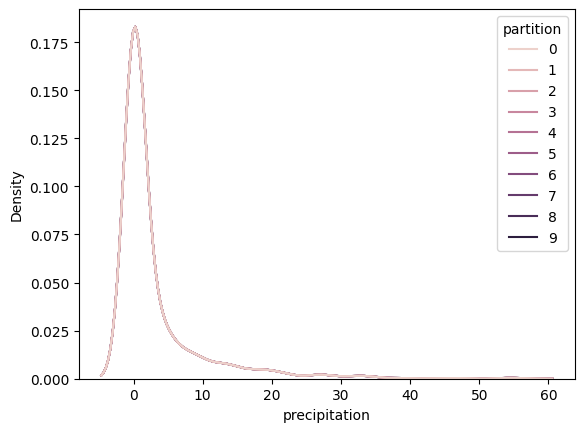

In [8]:
sns.kdeplot(merged_df, x="precipitation", hue="partition")
plt.show()

In [10]:
print(merged_df.head(100))

          date  precipitation  temp_max  temp_min  wind  partition
0   2012-01-01            NaN       NaN       NaN   NaN          0
1   2012-01-02           10.9       NaN       NaN   NaN          0
2   2012-01-03            NaN       NaN       NaN   NaN          0
3   2012-01-04            NaN       NaN       NaN   NaN          0
4   2012-01-05            NaN       NaN       2.8   NaN          0
..         ...            ...       ...       ...   ...        ...
95  2012-04-05            4.6       NaN       NaN   NaN          0
96  2012-04-06            NaN       NaN       NaN   2.6          0
97  2012-04-07            NaN       NaN       NaN   NaN          0
98  2012-04-08            NaN       NaN       NaN   NaN          0
99  2012-04-09            NaN      20.0       NaN   2.1          0

[100 rows x 6 columns]


In [11]:
merged_df.to_csv("merged_df.csv")